In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
df1 = pd.read_csv("../data/raw/intent_taxonomy.csv")
df2 = pd.read_csv("../data/raw/support_messages.csv")

In [8]:
df1.head(10)

,intent,description,priority,target_response_minutes
0,balance_enquiry,balance enquiry,normal,240
1,failed_transfer,failed transfer,high,60
2,tariff_question,tariff question,normal,240
3,app_technical,app technical,normal,240
4,pin_reset,pin reset,normal,240
5,account_opening,account opening,normal,240
6,agent_complaint,agent complaint,high,60
7,card_request,card request,normal,240
8,praise,praise,normal,240
9,fraud_report,fraud report,critical,15


In [5]:
df1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10 entries, 0 to 9
Data columns (total 4 columns):
 #   Column                   Non-Null Count  Dtype 
---  ------                   --------------  ----- 
 0   intent                   10 non-null     object
 1   description              10 non-null     object
 2   priority                 10 non-null     object
 3   target_response_minutes  10 non-null     int64 
dtypes: int64(1), object(3)
memory usage: 452.0+ bytes


In [6]:
df1.describe()

,target_response_minutes
count,10.000000
mean,181.500000
std,94.986841
min,15.000000
25%,105.000000
50%,240.000000
75%,240.000000
max,240.000000


In [4]:
df2.head()

,message_id,received_at,channel,message_text,language_hint,customer_tier,intent,resolved_minutes
0,MSG-001549,2026-05-15 20:21:00,whatsapp,bonjour the transfer ispending since yesterday,en,basic,failed_transfer,32
1,MSG-013890,23/02/2026 23:00,sms,hello money commot for ma account but e no lan...,mixed,plus,failed_transfer,88
2,MSG-025260,2026-05-20 23:36:00,sms,abeg l'application ne s'ouvre pas pls,fr,plus,app_technical,143
3,MSG-009296,2026-03-13 10:52:00,whatsapp,pls money commot for ma account but e no land,pi,plus,failed_transfer,88
4,MSG-010671,2025-10-13 12:29:00,sms,pls the app will not pen,en,basic,app_technical,103


In [7]:
df2.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 44600 entries, 0 to 44599
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   message_id        44600 non-null  object
 1   received_at       44600 non-null  object
 2   channel           44600 non-null  object
 3   message_text      44600 non-null  object
 4   language_hint     44600 non-null  object
 5   customer_tier     44600 non-null  object
 6   intent            44600 non-null  object
 7   resolved_minutes  44600 non-null  int64 
dtypes: int64(1), object(7)
memory usage: 2.7+ MB


In [11]:
intents_counts = df2.groupby("intent").count()

In [ ]:
intents_counts

,message_id,received_at,channel,message_text,language_hint,customer_tier,resolved_minutes
intent,,,,,,,
fraud_report,1026,1026,1026,1026,1026,1026,1026
praise,1083,1083,1083,1083,1083,1083,1083
card_request,2362,2362,2362,2362,2362,2362,2362
agent_complaint,3225,3225,3225,3225,3225,3225,3225
account_opening,3594,3594,3594,3594,3594,3594,3594
pin_reset,4725,4725,4725,4725,4725,4725,4725
app_technical,5327,5327,5327,5327,5327,5327,5327
tariff_question,5622,5622,5622,5622,5622,5622,5622
failed_transfer,7327,7327,7327,7327,7327,7327,7327


C:\Users\chris\AppData\Local\Temp\ipykernel_14056\2585337206.py:12: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')


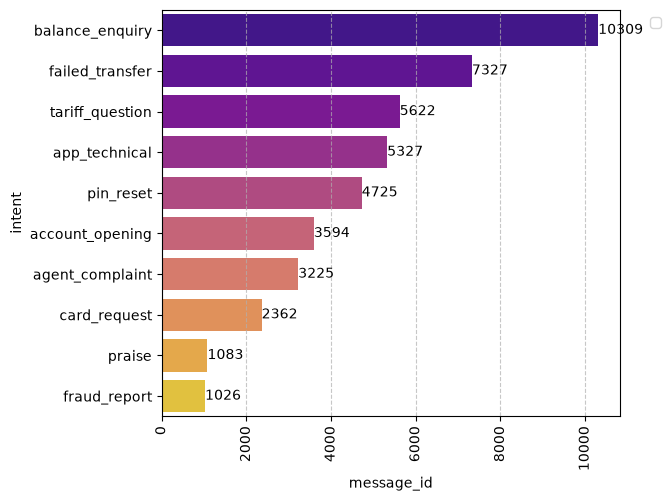

In [ ]:
plt.figure(figsize=(10, 6))
ax = sns.barplot(
    data=intents_counts.sort_values(by="message_id", ascending=False),
    x="message_id",
    y="intent",
    hue="intent",
    dodge=False,
    palette="plasma")
plt.tight_layout()

plt.xticks(rotation=90) 
ax.legend(*plt.gca().get_legend_handles_labels())
ax.grid(axis='x', linestyle='--', alpha=0.7)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')

for p in ax.patches:
    ax.annotate(f'{int(p.get_width())}',
                (p.get_width(), p.get_y()+p.get_height()/2),
                ha='left', va='center')